In [1]:
from google.cloud import bigquery
import pandas as pd
import os

# Aponta para o arquivo de credenciais que você baixou
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials.json"

# Cria o cliente BigQuery (é ele que faz as consultas)
client = bigquery.Client(project="gen-lang-client-0861123700")

print("Conexão com BigQuery configurada!")

Conexão com BigQuery configurada!


In [ ]:
# ver como os dados estão organizados
query_explorar = """
SELECT *
FROM `datario.adm_central_atendimento_1746.chamado`
LIMIT 5
"""

df_amostra = client.query(query_explorar).to_dataframe()

print("Colunas disponíveis:")
print(df_amostra.columns.tolist())
print("\nAmostra dos dados:")
print(df_amostra.head())

Colunas disponíveis:
['id_chamado', 'id_origem_ocorrencia', 'data_inicio', 'data_fim', 'id_bairro', 'id_territorialidade', 'id_logradouro', 'numero_logradouro', 'id_unidade_organizacional', 'nome_unidade_organizacional', 'id_unidade_organizacional_mae', 'unidade_organizacional_ouvidoria', 'categoria', 'id_tipo', 'tipo', 'id_subtipo', 'subtipo', 'status', 'longitude', 'latitude', 'data_alvo_finalizacao', 'data_alvo_diagnostico', 'data_real_diagnostico', 'tempo_prazo', 'prazo_unidade', 'prazo_tipo', 'dentro_prazo', 'situacao', 'tipo_situacao', 'justificativa_status', 'reclamacoes', 'extracted_at', 'updated_at', 'data_particao']

Amostra dos dados:
  id_chamado id_origem_ocorrencia         data_inicio            data_fim  \
0   23398826                    1 2026-05-01 01:39:50 2026-05-01 01:39:50   
1   23398822                    1 2026-05-01 01:35:13 2026-05-01 01:35:13   
2   23398802                   28 2026-05-01 00:42:44                 NaT   
3   23398823                    1 2026

In [3]:
query_tipos = """
SELECT tipo, subtipo, COUNT(*) as total
FROM `datario.adm_central_atendimento_1746.chamado`
GROUP BY tipo, subtipo
ORDER BY total DESC
LIMIT 50
"""

df_tipos = client.query(query_tipos).to_dataframe()
print(df_tipos.to_string())

                                         tipo                                                                                     subtipo    total
0                            Remoção Gratuita                                                       Remoção de entulho e bens inservíveis  2591358
1                    Estacionamento irregular                                         Fiscalização de estacionamento irregular de veículo  1804432
2                          Iluminação Pública                                                                   Reparo de lâmpada apagada   928990
3                                Pavimentação                                        Reparo de buraco, deformação ou afundamento na pista   546794
4                              Cadastro Único                                 Informações sobre inscrição e atualização do Cadastro Único   444868
5                      Limpeza de logradouros                                                           Remoção de res

In [6]:
query_alagamento = """
SELECT
    id_chamado,
    data_inicio,
    data_fim,
    tipo,
    subtipo,
    status,
    situacao,
    id_bairro,
    latitude,
    longitude
FROM `datario.adm_central_atendimento_1746.chamado`
WHERE
    LOWER(tipo) LIKE '%drenagem%'
    OR LOWER(tipo) LIKE '%alagamento%'
    OR LOWER(subtipo) LIKE '%alagamento%'
    OR LOWER(subtipo) LIKE '%enchente%'
    OR LOWER(subtipo) LIKE '%inundac%'
    OR LOWER(subtipo) LIKE '%pluvial%'
    OR LOWER(subtipo) LIKE '%bueiro%'
ORDER BY data_inicio
"""

print("Rodando consulta...")
df_alagamento = client.query(query_alagamento).to_dataframe()

print(f"\nConcluído!")
print(f"Total de chamados: {len(df_alagamento):,}")
print(f"\nSubtipos encontrados:")
print(df_alagamento["subtipo"].value_counts())

Rodando consulta...

Concluído!
Total de chamados: 554,802

Subtipos encontrados:
subtipo
Manutenção/Desobstrução de ramais de águas pluviais e ralos                                                                       243623
Reposição de tampão ou grelha                                                                                                     107447
Conservação de bueiros, galerias, ramais de águas pluviais e ralos                                                                 52162
Desobstrução de ramais de ralos                                                                                                    30976
Informações sobre desentupimento ou reparo de rede de esgoto em logradouros públicos                                               30293
Obras de reparo, canalização ou limpeza de rio, canal ou valão - solicitação                                                       18219
Informações sobre Esgotamento Sanitário                                                 

In [7]:
# Converte datas
df_alagamento["data_inicio"] = pd.to_datetime(df_alagamento["data_inicio"], errors="coerce")
df_alagamento["data_fim"] = pd.to_datetime(df_alagamento["data_fim"], errors="coerce")

# Remove linhas sem data válida
antes = len(df_alagamento)
df_alagamento = df_alagamento.dropna(subset=["data_inicio"])
depois = len(df_alagamento)
print(f"Linhas removidas por data inválida: {antes - depois}")

# Cria colunas auxiliares
df_alagamento["data"]       = df_alagamento["data_inicio"].dt.date
df_alagamento["ano"]        = df_alagamento["data_inicio"].dt.year
df_alagamento["mes"]        = df_alagamento["data_inicio"].dt.month
df_alagamento["hora"]       = df_alagamento["data_inicio"].dt.hour
df_alagamento["dia_semana"] = df_alagamento["data_inicio"].dt.dayofweek

print(f"\nPeríodo coberto:")
print(f"  Início: {df_alagamento['data_inicio'].min()}")
print(f"  Fim:    {df_alagamento['data_inicio'].max()}")
print(f"\nDistribuição por ano:")
print(df_alagamento.groupby("ano").size().sort_index())

Linhas removidas por data inválida: 0

Período coberto:
  Início: 2010-06-01 00:00:00
  Fim:    2026-04-30 22:21:29

Distribuição por ano:
ano
2010     1753
2011    17068
2012    28736
2013    41957
2014    29097
2015    26306
2016    30683
2017    26630
2018    30496
2019    33260
2020    21473
2021    28344
2022    32915
2023    63146
2024    67845
2025    54274
2026    20819
dtype: int64


In [8]:
# Busca a tabela de bairros do Data.Rio para cruzar com id_bairro
query_bairros = """
SELECT id_bairro, nome AS bairro
FROM `datario.dados_mestres.bairro`
"""

print("Buscando tabela de bairros...")
df_bairros = client.query(query_bairros).to_dataframe()

print(f"{len(df_bairros)} bairros encontrados")
print(df_bairros.head(10))

Buscando tabela de bairros...
166 bairros encontrados
  id_bairro        bairro
0         2        Gamboa
1         3  Santo Cristo
2         4          Caju
3         1         Saúde
4         5        Centro
5       161          Lapa
6        13       Paquetá
7        14  Santa Teresa
8         8   Cidade Nova
9         7  Rio Comprido


In [9]:
# Cruzar df_alagamento com df_bairros pelo id_bairro
df_alagamento["id_bairro"] = df_alagamento["id_bairro"].astype(str)
df_bairros["id_bairro"] = df_bairros["id_bairro"].astype(str)

df_alagamento = df_alagamento.merge(df_bairros, on="id_bairro", how="left")

# Padroniza nome do bairro
df_alagamento["bairro"] = (
    df_alagamento["bairro"]
    .str.strip()
    .str.upper()
    .str.normalize("NFC")
)

# Verifica quantos ficaram sem bairro
sem_bairro = df_alagamento["bairro"].isna().sum()
print(f"Chamados sem bairro identificado: {sem_bairro:,} ({sem_bairro/len(df_alagamento)*100:.1f}%)")

print(f"\nTop 20 bairros com mais chamados de drenagem/alagamento:")
print(df_alagamento["bairro"].value_counts().head(20))

Chamados sem bairro identificado: 35,216 (6.3%)

Top 20 bairros com mais chamados de drenagem/alagamento:
bairro
CAMPO GRANDE                42890
SANTA CRUZ                  23034
BANGU                       21237
GUARATIBA                   21154
REALENGO                    17441
CENTRO                      15611
SEPETIBA                    13781
PACIÊNCIA                   11379
TIJUCA                      11036
TAQUARA                     10447
BARRA DA TIJUCA              8558
JACAREPAGUÁ                  8421
RECREIO DOS BANDEIRANTES     8280
BOTAFOGO                     8192
COPACABANA                   7921
MADUREIRA                    7840
COSMOS                       7633
PADRE MIGUEL                 6883
INHOAÍBA                     6839
IRAJÁ                        5809
Name: count, dtype: int64


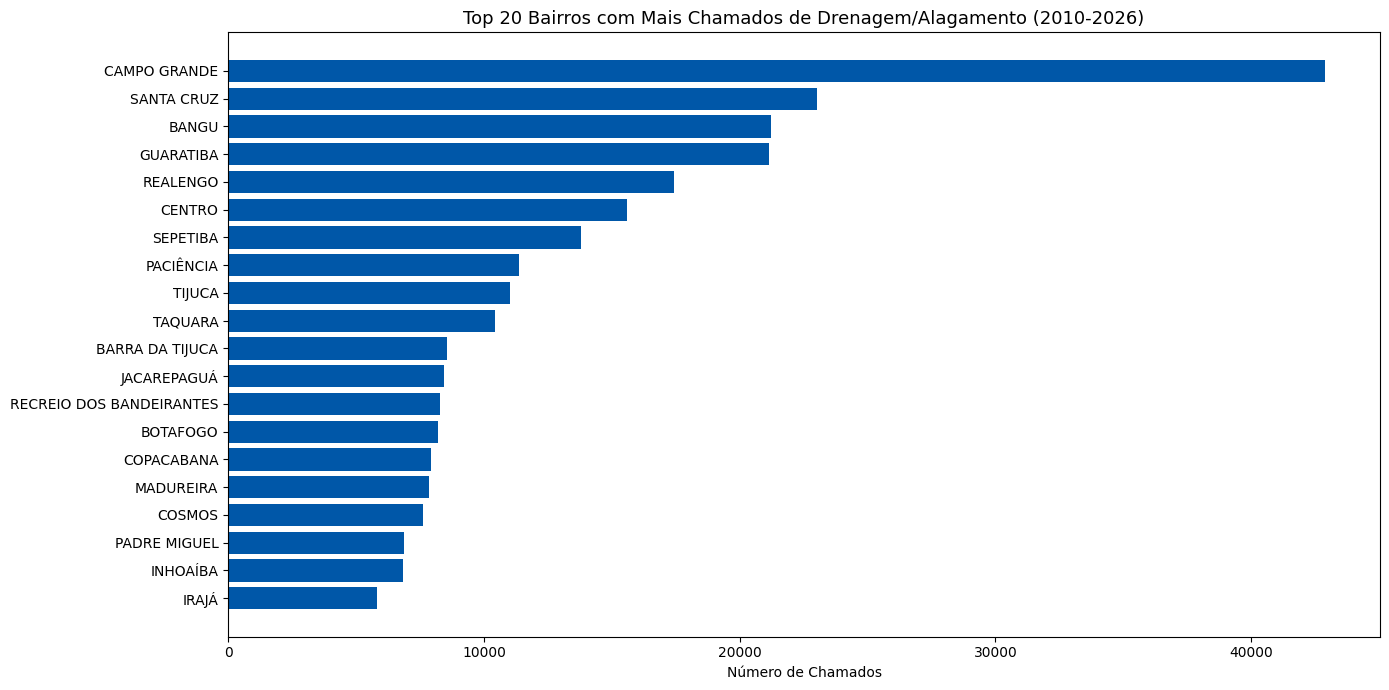

Gráfico 1 salvo


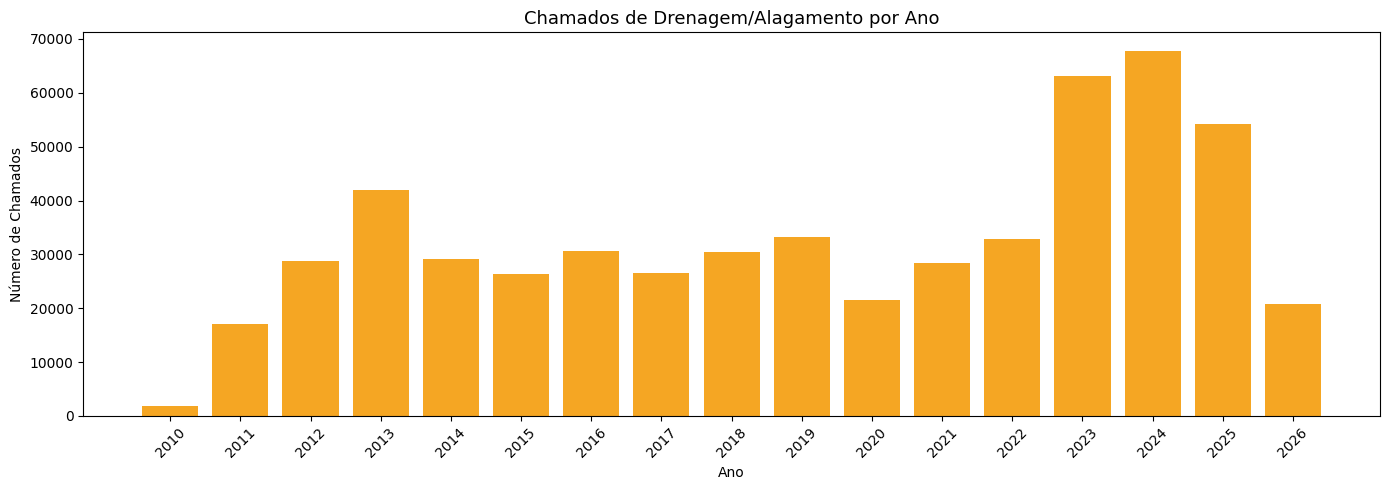

Gráfico 2 salvo


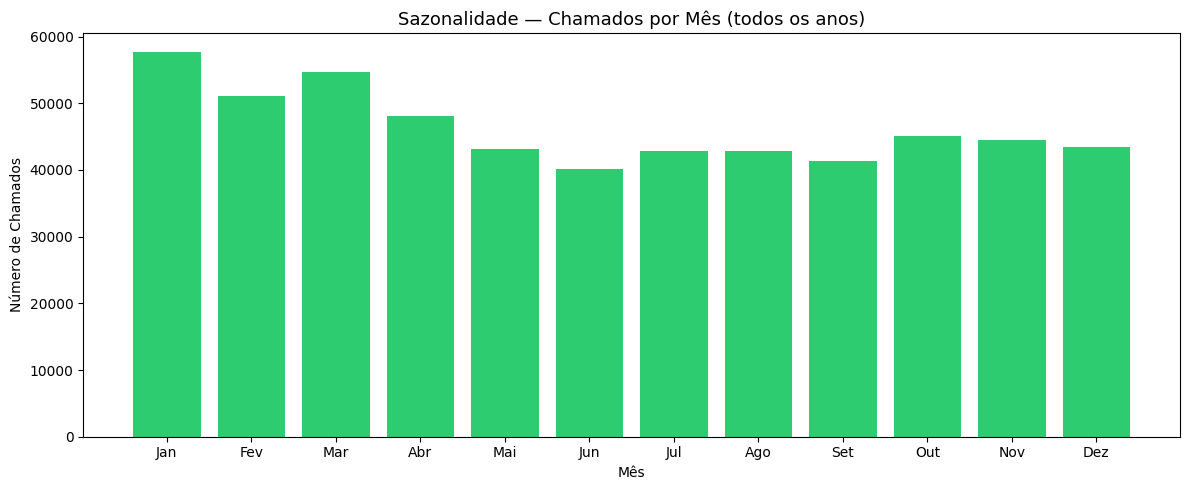

Gráfico 3 salvo


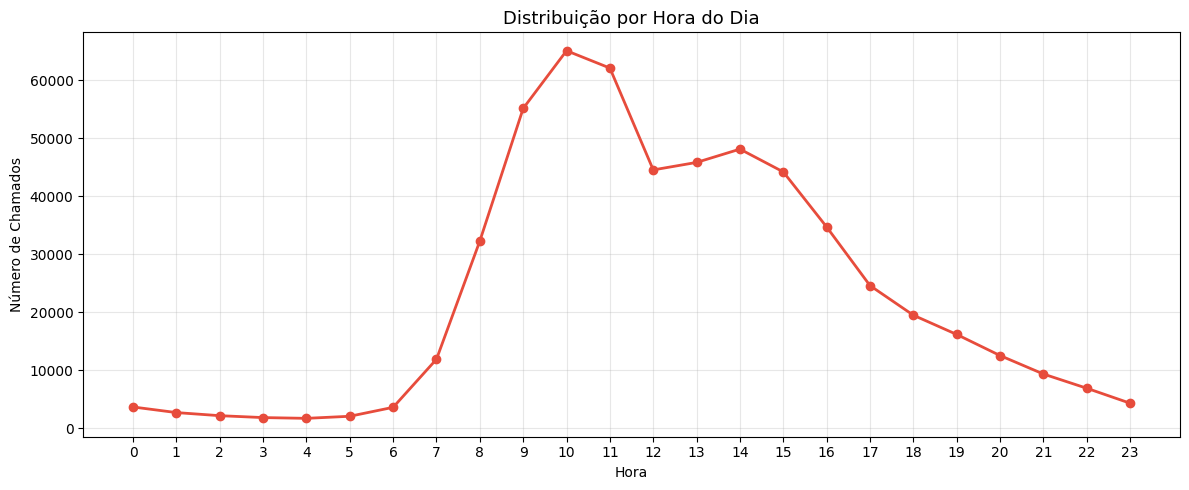

Gráfico 4 salvo


In [12]:
import matplotlib.pyplot as plt
import os

os.makedirs("../figuras", exist_ok=True)

# === GRÁFICO 1: Top 20 bairros ===
top20 = df_alagamento["bairro"].value_counts().head(20)

plt.figure(figsize=(14, 7))
plt.barh(top20.index[::-1], top20.values[::-1], color="#0057A8")
plt.title("Top 20 Bairros com Mais Chamados de Drenagem/Alagamento (2010-2026)", fontsize=13)
plt.xlabel("Número de Chamados")
plt.tight_layout()
plt.savefig("../figuras/top20_bairros.png", dpi=150)
plt.show()
print("Gráfico 1 salvo")

# === GRÁFICO 2: Chamados por ano ===
por_ano = df_alagamento.groupby("ano").size()

plt.figure(figsize=(14, 5))
plt.bar(por_ano.index, por_ano.values, color="#F5A623")
plt.title("Chamados de Drenagem/Alagamento por Ano", fontsize=13)
plt.xlabel("Ano")
plt.ylabel("Número de Chamados")
plt.xticks(por_ano.index, rotation=45)
plt.tight_layout()
plt.savefig("../figuras/chamados_por_ano.png", dpi=150)
plt.show()
print("Gráfico 2 salvo")

# === GRÁFICO 3: Chamados por mês ===
por_mes = df_alagamento.groupby("mes").size()
meses = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

plt.figure(figsize=(12, 5))
plt.bar(meses, por_mes.values, color="#2ECC71")
plt.title("Sazonalidade — Chamados por Mês (todos os anos)", fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Número de Chamados")
plt.tight_layout()
plt.savefig("../figuras/chamados_por_mes.png", dpi=150)
plt.show()
print("Gráfico 3 salvo")

# === GRÁFICO 4: Chamados por hora do dia ===
por_hora = df_alagamento.groupby("hora").size()

plt.figure(figsize=(12, 5))
plt.plot(por_hora.index, por_hora.values, color="#E74C3C", linewidth=2, marker="o")
plt.title("Distribuição por Hora do Dia", fontsize=13)
plt.xlabel("Hora")
plt.ylabel("Número de Chamados")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../figuras/chamados_por_hora.png", dpi=150)
plt.show()
print("Gráfico 4 salvo")

In [11]:
import pyarrow
import os

caminho = "../data/processed/chamados_alagamento.parquet"

df_alagamento.to_parquet(caminho, index=False)

df_teste = pd.read_parquet(caminho)
print(f"Arquivo salvo com sucesso!")
print(f"   Linhas: {len(df_teste):,}")
print(f"   Colunas: {df_teste.columns.tolist()}")
print(f"\nResumo final:")
print(f"  Período: {df_teste['ano'].min()} a {df_teste['ano'].max()}")
print(f"  Bairros únicos: {df_teste['bairro'].nunique()}")
print(f"  Subtipos únicos: {df_teste['subtipo'].nunique()}")

Arquivo salvo com sucesso!
   Linhas: 554,802
   Colunas: ['id_chamado', 'data_inicio', 'data_fim', 'tipo', 'subtipo', 'status', 'situacao', 'id_bairro', 'latitude', 'longitude', 'data', 'ano', 'mes', 'hora', 'dia_semana', 'bairro']

Resumo final:
  Período: 2010 a 2026
  Bairros únicos: 166
  Subtipos únicos: 55
